## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [8]:
df = pd.read_csv("loan_approval_dataset.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP100000,Male,Yes,2,Graduate,Yes,3786,6033,102,180,1.0,Urban,Y
1,LP100001,Male,Yes,1,Graduate,Yes,10695,1628,329,360,1.0,Rural,Y
2,LP100002,Female,Yes,1,Not Graduate,No,6052,1273,160,300,1.0,Semiurban,Y
3,LP100003,Male,No,2,Not Graduate,Yes,13455,3763,324,180,0.0,Semiurban,N
4,LP100004,Male,No,2,Graduate,Yes,2250,5417,166,300,0.0,Urban,N


## 3. Explore Dataset

In [9]:
print(df.shape)
df.info()
df.describe(include='all')
df.isnull().sum()

(500, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            500 non-null    object 
 1   Gender             500 non-null    object 
 2   Married            500 non-null    object 
 3   Dependents         500 non-null    object 
 4   Education          500 non-null    object 
 5   Self_Employed      500 non-null    object 
 6   ApplicantIncome    500 non-null    int64  
 7   CoapplicantIncome  500 non-null    int64  
 8   LoanAmount         500 non-null    int64  
 9   Loan_Amount_Term   500 non-null    int64  
 10  Credit_History     500 non-null    float64
 11  Property_Area      500 non-null    object 
 12  Loan_Status        500 non-null    object 
dtypes: float64(1), int64(4), object(8)
memory usage: 50.9+ KB


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

## 4. Data Preprocessing

In [10]:
# Remove unwanted columns if present
for col in ['Loan_ID','loan_id','ID']:
    if col in df.columns:
        df = df.drop(columns=col)

target = 'Loan_Status' if 'Loan_Status' in df.columns else df.columns[-1]

X = df.drop(columns=target)
y = df[target]

categorical = X.select_dtypes(include='object').columns
numerical = X.select_dtypes(exclude='object').columns

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
], remainder='passthrough')

## 5. Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 6. Decision Tree Classifier

Accuracy: 1.0
              precision    recall  f1-score   support

           N       1.00      1.00      1.00        18
           Y       1.00      1.00      1.00        82

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



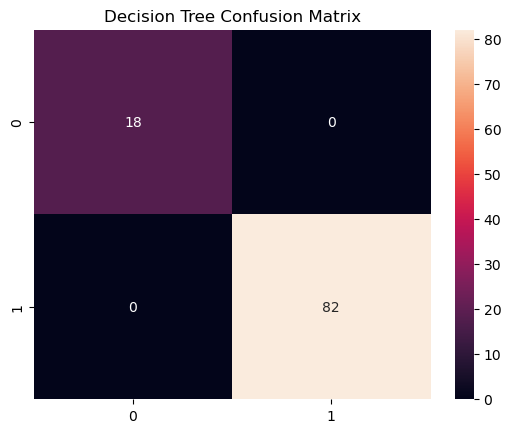

In [12]:
dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

cm = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.show()

## 7. Random Forest Classifier

Accuracy: 1.0
              precision    recall  f1-score   support

           N       1.00      1.00      1.00        18
           Y       1.00      1.00      1.00        82

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



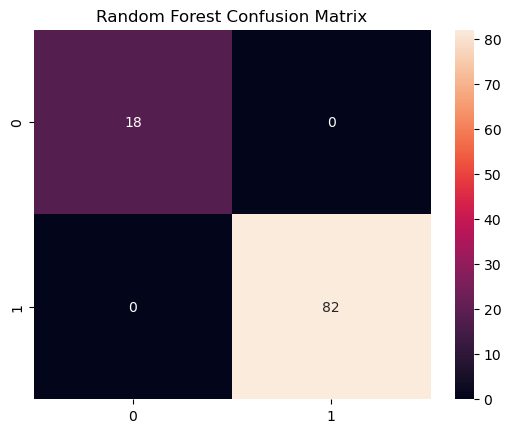

In [13]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

## 8. Model Comparison

           Model  Accuracy
0  Decision Tree       1.0
1  Random Forest       1.0


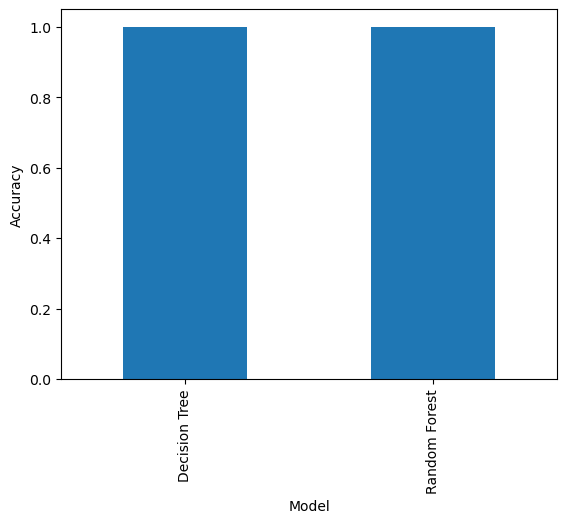

In [14]:
results = pd.DataFrame({
    'Model':['Decision Tree','Random Forest'],
    'Accuracy':[
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

print(results)

results.plot(x='Model', y='Accuracy', kind='bar', legend=False)
plt.ylabel("Accuracy")
plt.show()

## 9. Practice Exercises
1. Change the Decision Tree max_depth.
2. Change the number of Random Forest estimators.
3. Compare the accuracies.
4. Try another train-test split ratio.